# Evaluation: Comparing Transformer, Snippet, and Hybrid Approaches

This notebook evaluates and compares the results of the three sentiment analysis approaches:
- DistilBERT baseline
- Snippet-based lexicon scoring
- Hybrid fusion (BERT + Snippet)

We use distribution analysis, company/year breakdowns, and error inspection to assess performance.

In [18]:
# 1. Setup
import pandas as pd
import matplotlib.pyplot as plt

# Load 5-class CSVs
baseline = pd.read_csv("../data/processed/distilbert_baseline_5class.csv")
snippet = pd.read_csv("../data/processed/snippet_scores_5class.csv")
hybrid_doc = pd.read_csv("../data/processed/hybrid_scores_5class.csv")

print(f"✅ Baseline loaded: {baseline.shape}")
print(f"✅ Snippet loaded: {snippet.shape}")
print(f"✅ Hybrid_doc loaded: {hybrid_doc.shape}")

# Define consistent class order and colors (positives = green, negatives = red, neutral = gray)
class_order = ["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE"]
colors = {
    "VERY NEGATIVE": "red",
    "NEGATIVE": "red",
    "NEUTRAL": "gray",
    "POSITIVE": "green",
    "VERY POSITIVE": "green"
}

✅ Baseline loaded: (14166, 6)
✅ Snippet loaded: (14166, 8)
✅ Hybrid_doc loaded: (9, 7)


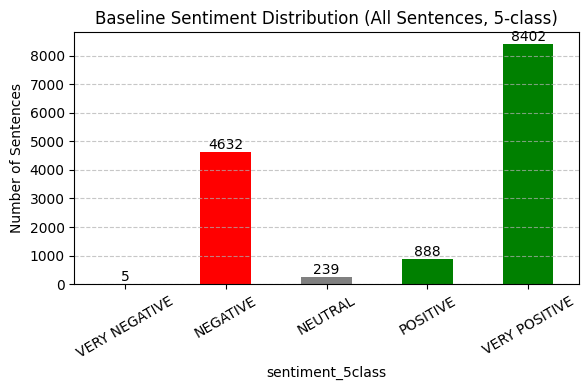

In [19]:
# 2: Baseline distribution with bar labels
baseline_counts = baseline['sentiment_5class'].value_counts().reindex(class_order)

ax = baseline_counts.plot(kind='bar', color=[colors[c] for c in class_order], figsize=(6,4))
ax.set_title("Baseline Sentiment Distribution (All Sentences, 5-class)")
ax.set_ylabel("Number of Sentences")
ax.bar_label(ax.containers[0])  # add values on top of bars

plt.xticks(rotation=30)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("../images/eval_baseline_distribution.png", dpi=300)
plt.show()

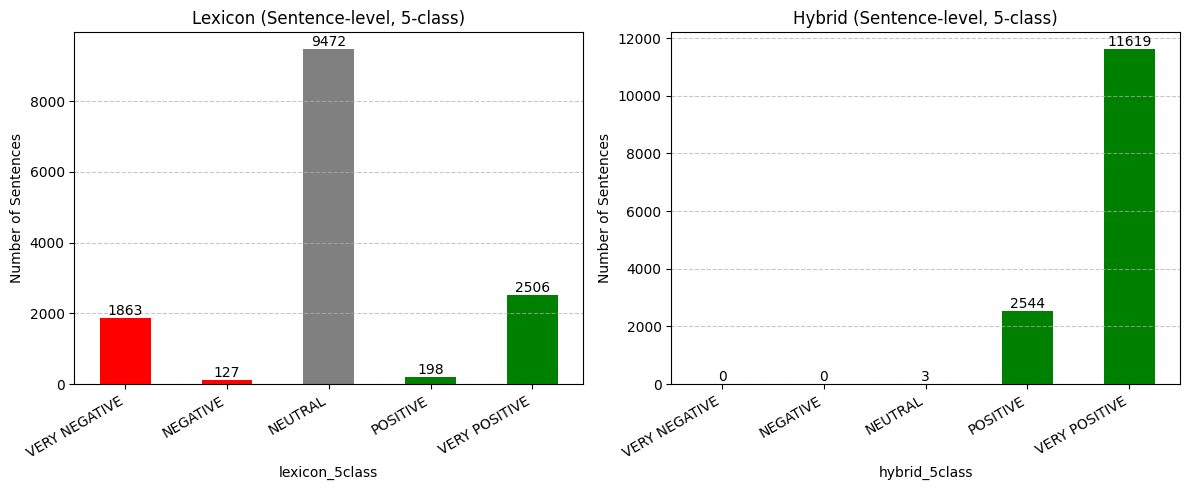

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load sentence-level results
lexicon = pd.read_csv("../data/processed/lexicon_5class_sentencelevel.csv")
hybrid  = pd.read_csv("../data/processed/hybrid_5class_sentencelevel.csv")

# Define class order and colors
class_order = ["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE"]
colors = {
    "VERY NEGATIVE": "red",
    "NEGATIVE": "red",
    "NEUTRAL": "gray",
    "POSITIVE": "green",
    "VERY POSITIVE": "green"
}

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Lexicon (sentence-level)
lexicon_counts = lexicon['lexicon_5class'].value_counts().reindex(class_order, fill_value=0)
lexicon_counts.plot(kind="bar", ax=ax[0], color=[colors[c] for c in lexicon_counts.index])
ax[0].set_title("Lexicon (Sentence-level, 5-class)")
ax[0].set_ylabel("Number of Sentences")
ax[0].bar_label(ax[0].containers[0], labels=[str(x) for x in lexicon_counts])
ax[0].grid(True, axis="y", linestyle="--", alpha=0.7)
ax[0].set_xticklabels(class_order, rotation=30, ha='right')

# Hybrid (sentence-level)
hybrid_counts = hybrid['hybrid_5class'].value_counts().reindex(class_order, fill_value=0)
hybrid_counts.plot(kind="bar", ax=ax[1], color=[colors[c] for c in hybrid_counts.index])
ax[1].set_title("Hybrid (Sentence-level, 5-class)")
ax[1].set_ylabel("Number of Sentences")
ax[1].bar_label(ax[1].containers[0], labels=[str(x) for x in hybrid_counts])
ax[1].grid(True, axis="y", linestyle="--", alpha=0.7)
ax[1].set_xticklabels(class_order, rotation=30, ha='right')

plt.tight_layout()
plt.savefig("../images/eval_hybrid_sentencelevel_comparison.png", dpi=300)
plt.show()

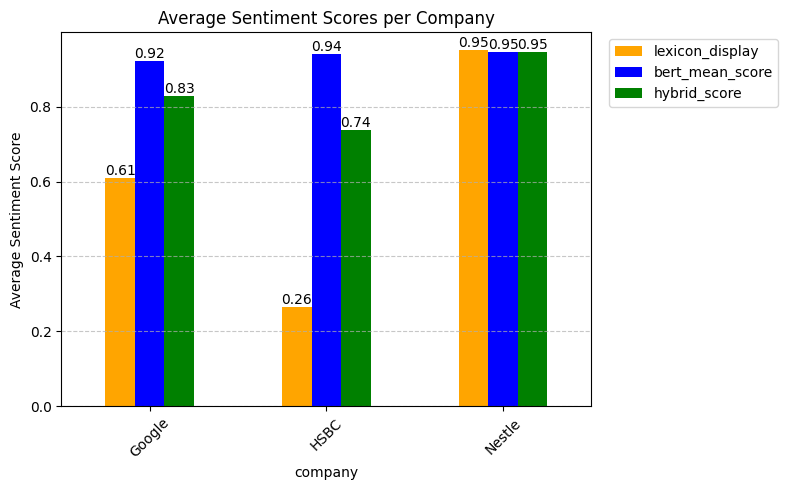

In [21]:
# 4. Company-level aggregation
hybrid_doc['lexicon_display'] = (hybrid_doc['lexicon_score'] - hybrid_doc['lexicon_score'].min()) / (hybrid_doc['lexicon_score'].max() - hybrid_doc['lexicon_score'].min())

company_means = hybrid_doc.groupby("company")[["lexicon_display","bert_mean_score","hybrid_score"]].mean()

ax = company_means.plot(
    kind="bar",
    figsize=(8,5),
    color=["orange","blue","green"]
)
ax.set_title("Average Sentiment Scores per Company")
ax.set_ylabel("Average Sentiment Score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig("../images/eval_company_means.png", dpi=300, bbox_inches='tight')
plt.show()


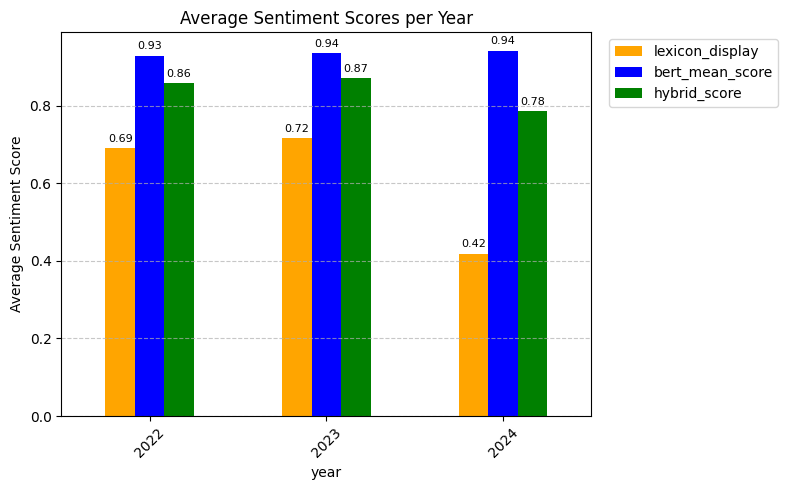

In [22]:
# 5. Year-level aggregation
year_means = hybrid_doc.groupby("year")[["lexicon_display","bert_mean_score","hybrid_score"]].mean()

ax = year_means.plot(kind="bar", figsize=(8,5), color=["orange","blue","green"])
ax.set_title("Average Sentiment Scores per Year")
ax.set_ylabel("Average Sentiment Score")

# Bar label'ları ekle
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

# Legendi grafiğin dışına taşı
ax.legend(loc='upper left', bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.savefig("../images/eval_year_means.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# 6. Error inspection: sample sentences with potential misclassification
# Pick a few sample sentences from Baseline (sentence-level)
sample_baseline = baseline.groupby(["company","year"]).head(3)

# Merge with Hybrid doc-level scores
sample_errors = pd.merge(
    sample_baseline,
    hybrid[["company","year","hybrid_score"]],
    on=["company","year"],
    how="left"
)

print("Sample inspection:")
print(sample_errors[["company","year","sentence","sentiment_5class","score","hybrid_score"]].head(10))

Sample inspection:
  company  year                                           sentence  \
0  Google  2022  environmental report table of contents 1 about...   
1  Google  2022  environmental report table of contents 1 about...   
2  Google  2022  environmental report table of contents 1 about...   
3  Google  2022  environmental report table of contents 1 about...   
4  Google  2022  environmental report table of contents 1 about...   
5  Google  2022  environmental report table of contents 1 about...   
6  Google  2022  environmental report table of contents 1 about...   
7  Google  2022  environmental report table of contents 1 about...   
8  Google  2022  environmental report table of contents 1 about...   
9  Google  2022  environmental report table of contents 1 about...   

  sentiment_5class     score  hybrid_score  
0    VERY POSITIVE  0.902096      0.931467  
1    VERY POSITIVE  0.902096      0.680859  
2    VERY POSITIVE  0.902096      0.999484  
3    VERY POSITIVE  0.902096  